# Guia Itaú — Capítulos de Alto Impacto

### Um adendo ao seu guia, focado no que mais separa "aprovado" de "reprovado"

Lucas, este caderno **não substitui** o seu guia. Ele entra como um capítulo extra,
escrito para tapar as três lacunas que mais pesam numa prova de Cientista de Dados
**de banco** — e que, por serem específicas, costumam ser o fiel da balança:

1. **A regra da penalidade** — a parte de *estratégia* da prova. É matemática de
   decisão pura, vale pontos de graça, e quase ninguém otimiza.
2. **KS e Gini a fundo** — as métricas que o Itaú vive no dia a dia (credit scoring).
   Seu guia as cita, mas não te ensina a calcular e interpretar de verdade. Aqui eu
   ensino do zero, na mão e no `sklearn`.
3. **Validação completa** — incluindo *out-of-time*, o conceito de validação que só
   existe de verdade em banco (por causa de safra e drift) e que a ementa cobra.

No fim tem um **simulado novo de 24 questões**, com o gabarito **distribuído de
verdade** entre a, b, c e d — porque um simulado em que a resposta é quase sempre a
mesma letra treina o reflexo errado e te dá uma falsa sensação de domínio.

### Como ler isto
Cada capítulo segue a mesma espinha: **a situação → a intuição → a matemática →
o código que roda → como falar na sabatina.** Leia na ordem. Digite os códigos (na
prova prática você escreve `sklearn` de cabeça, sem IA, sem Google). E faça o
simulado **cronometrado e sem consulta** só depois de ler os três capítulos.

# Capítulo 1 — A regra da penalidade (a estratégia que vale pontos)

> "O teste tem um sistema de correção: a cada resposta errada, uma correta é
> anulada. Portanto, se não souber, deixe em branco." — orientações da prova

Traduzindo para a nota: cada **acerto vale +1**, cada **erro vale −1**, e cada
**branco vale 0**. A sua nota é `acertos − erros`. Isso muda completamente a
estratégia, e a maioria dos candidatos não percebe.

### A pergunta que decide tudo: vale a pena chutar?

A resposta não é "sim" nem "não" — é **depende de quantas alternativas você
consegue eliminar**. Vamos calcular o *valor esperado* (a média do que você ganha,
se repetisse aquela aposta muitas vezes) para uma questão de 4 alternativas:

- Chute **cego** (4 candidatas, chance de acerto = 1/4):
  `E = (1/4)(+1) + (3/4)(−1) = −0,50`. **Negativo.** Em média você PERDE meio ponto.
- Eliminou 1, sobram 3 (chance 1/3): `E = (1/3)(+1) + (2/3)(−1) = −0,33`. Ainda negativo.
- Eliminou 2, sobram 2 (chance 1/2): `E = (1/2)(+1) + (1/2)(−1) = 0`. **Neutro.**
- Eliminou 3, sobra 1: `E = +1`. Óbvio: marque.

### A regra de ouro (decore isto)

> **Só responda se conseguir eliminar pelo menos 2 alternativas** (ou seja, ficar
> com no máximo 2 candidatas). Se ainda tiver 3 ou 4 na dúvida, **deixe em branco** —
> chutar, na média, derruba sua nota.

Esse "na média" é importante: numa questão isolada o chute pode acertar. Mas ao
longo de 60 questões, a estatística cobra. Branco não é covardia — é gestão de risco.

In [1]:
# A conta da penalidade, para você ver com seus olhos (erro cancela 1 acerto)
print('Valor esperado do chute numa questao de 4 alternativas')
print('(acerto = +1, erro = -1, branco = 0)')
print('-'*58)
print(f'{"alternativas eliminadas":<26}{"sobram":>7}{"P(acerto)":>11}{"E[ganho]":>10}')
print('-'*58)
for elim in [0, 1, 2, 3]:
    sobram = 4 - elim
    p = 1 / sobram
    ev = p * (+1) + (1 - p) * (-1)
    veredito = 'NAO chute' if ev < 0 else ('indiferente' if ev == 0 else 'MARQUE')
    print(f'{elim:<26}{sobram:>7}{p:>11.2f}{ev:>+10.2f}   <- {veredito}')
print('-'*58)
print('REGRA DE OURO: so responda se eliminar >= 2 alternativas.')
print('Caso contrario, branco vale mais que chute.')

Valor esperado do chute numa questao de 4 alternativas
(acerto = +1, erro = -1, branco = 0)
----------------------------------------------------------
alternativas eliminadas    sobram  P(acerto)  E[ganho]
----------------------------------------------------------
0                               4       0.25     -0.50   <- NAO chute
1                               3       0.33     -0.33   <- NAO chute
2                               2       0.50     +0.00   <- indiferente
3                               1       1.00     +1.00   <- MARQUE
----------------------------------------------------------
REGRA DE OURO: so responda se eliminar >= 2 alternativas.
Caso contrario, branco vale mais que chute.


### Os outros dois cuidados que custam pontos caros

**1. "Não passe as perguntas sem responder; ao chegar na última, o teste encerra."**
Isso é uma armadilha de navegação. Significa que você **não volta**. Então:
- Não deixe questão "para depois" achando que revisita — você não revisita.
- Decida na hora: sei (marco) / elimino 2+ (marco a melhor) / não faço ideia (branco) → e segue.
- **Nunca** avance até a última sem ter passado por todas, porque o teste fecha sozinho.

**2. Gestão das 4 horas.** São 4h para a prova prática. Orçamento sugerido:
- **30 min** lendo o problema e decidindo o tipo (regressão / classificação / clustering) antes de tocar no teclado. Pressa aqui custa caro depois.
- **Deixe 20 min no fim** para rodar tudo de novo limpo e conferir se não quebrou nada.
- Se travar num ponto por mais de ~10 min, entregue o "suficiente que roda" e siga. Um modelo simples que funciona e está avaliado vale mais que um sofisticado pela metade.

# Capítulo 2 — KS e Gini a fundo (as métricas do banco)

## Passo 1 — A situação

Você construiu um modelo de risco. Para cada cliente, ele cospe um **score**: a
probabilidade de a pessoa virar **mau pagador** (inadimplente). Score alto = arriscado.

A pergunta do banco **não é** "qual a acurácia?". É outra, mais afiada:

> "O seu score consegue **separar** quem paga de quem não paga? Se eu ordenar todo
> mundo pelo score, os maus se concentram no topo?"

Essa capacidade de *separar* tem duas medidas-rainha em crédito: o **KS** e o **Gini**.
Saber explicá-las e calculá-las é praticamente um pré-requisito para a vaga, porque é
o vocabulário do dia a dia de um cientista de dados de banco.

## Passo 2 — A intuição (a imagem que gruda)

Imagine duas filas, ordenadas pelo score, da esquerda (score baixo) para a direita
(score alto):
- A fila dos **bons** pagadores.
- A fila dos **maus** pagadores.

Se o modelo presta, os **maus** se amontoam à **direita** (score alto) e os **bons**
à **esquerda**. As duas distribuições ficam *afastadas* uma da outra.

- O **KS** mede **o ponto onde essas duas filas estão mais afastadas** — a maior
  distância vertical entre as curvas acumuladas das duas. É um número de 0 a 1.
- O **Gini** mede **a separação global** ao longo de toda a régua de score, e está
  colado no AUC pela fórmula `Gini = 2·AUC − 1`.

KS olha **o melhor ponto de corte**; Gini olha **a separação inteira**. Por isso os
dois são reportados juntos: um diz "qual o melhor lugar para cortar", o outro diz
"quão bem o score ordena no geral".

## Passo 3 — A matemática (sem susto)

**KS (Kolmogorov–Smirnov).** Para cada valor de score `s`, calcule duas proporções
*acumuladas*:
- `F_maus(s)` = fração dos maus com score ≤ s
- `F_bons(s)` = fração dos bons com score ≤ s

O KS é a **maior diferença** entre essas duas curvas:

```
KS = máx sobre s de | F_maus(s) − F_bons(s) |
```

Em português: percorra o score do menor ao maior, vá acumulando quantos % dos maus e
quantos % dos bons você já "passou", e anote onde o **vão entre as duas curvas** é maior.
Esse vão máximo é o KS, e o score onde ele acontece é um **bom ponto de corte** sugerido.

**Gini.** Vem da curva ROC. A ROC é o gráfico de `TPR` (quantos maus você pega) contra
`FPR` (quantos bons você acusa errado) conforme move o corte. A **área sob a ROC** é o
`AUC` (0,5 = aleatório, 1,0 = perfeito). O Gini reescala isso para uma régua mais
intuitiva, onde 0 = aleatório:

```
Gini = 2·AUC − 1
```

Um Gini de 0,924 significa que o modelo está muito perto do separador perfeito.

## Passo 4 — O jargão (cada termo definido agora)

- **Score:** a saída contínua do modelo (aqui, probabilidade de ser mau).
- **CDF (distribuição acumulada):** "que fração da população já passei até este ponto".
  É o `F(s)` acima. É o mesmo CDF da ementa de estatística — aqui aplicado a maus e bons.
- **Tabela de KS (ou tabela de decis):** o formato real do banco. Você divide a
  população em 10 faixas de score (decis), e em cada faixa acumula % de maus e % de
  bons. A maior diferença acumulada é o KS. É assim que aparece num relatório de modelo.
- **Curva de Lorenz / curva de ganho:** a prima da ROC usada para enxergar o Gini —
  quanto a curva "incha" para fora da diagonal, maior o Gini.

In [2]:
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------------------
# Dados simulados: score = probabilidade de ser MAU pagador.
# maus tendem a score ALTO; bons tendem a score BAIXO.
# ---------------------------------------------------------------
np.random.seed(42)
maus_score = np.random.beta(5, 2, 700)     # 700 maus, score alto
bons_score = np.random.beta(2, 5, 1300)    # 1300 bons, score baixo
score = np.concatenate([maus_score, bons_score])
y     = np.concatenate([np.ones(700), np.zeros(1300)]).astype(int)  # 1 = mau

# ===== AUC e Gini (o jeito direto) =====
auc  = roc_auc_score(y, score)
gini = 2 * auc - 1

# ===== KS NA MAO (a definicao, passo a passo) =====
d = pd.DataFrame({'score': score, 'mau': y}).sort_values('score').reset_index(drop=True)
total_maus = d['mau'].sum()
total_bons = (1 - d['mau']).sum()
d['cdf_maus'] = d['mau'].cumsum() / total_maus            # fracao de maus ja acumulada
d['cdf_bons'] = (1 - d['mau']).cumsum() / total_bons      # fracao de bons ja acumulada
d['gap']      = (d['cdf_maus'] - d['cdf_bons']).abs()     # o vao entre as curvas
ks       = d['gap'].max()
score_ks = d.loc[d['gap'].idxmax(), 'score']

print('=== AS TRES METRICAS DE SEPARACAO ===')
print(f'  AUC                 = {auc:.3f}   (0.5 = aleatorio, 1.0 = perfeito)')
print(f'  Gini = 2*AUC - 1    = {gini:.3f}   (0 = aleatorio, 1 = perfeito)')
print(f'  KS                  = {ks:.3f}   no score de corte ~ {score_ks:.3f}')

=== AS TRES METRICAS DE SEPARACAO ===
  AUC                 = 0.962   (0.5 = aleatorio, 1.0 = perfeito)
  Gini = 2*AUC - 1    = 0.924   (0 = aleatorio, 1 = perfeito)
  KS                  = 0.785   no score de corte ~ 0.494


In [3]:
# ===== A TABELA DE KS POR FAIXA (o formato do relatorio de banco) =====
# Divide em 10 faixas de score; acumula % de maus e % de bons; o maior vao e o KS.
df = pd.DataFrame({'score': score, 'mau': y})
df['faixa'] = pd.qcut(df['score'], 10, labels=False, duplicates='drop')

tab = (df.groupby('faixa')
         .agg(qtd=('mau', 'size'), maus=('mau', 'sum'))
         .sort_index(ascending=False))          # da faixa mais arriscada (9) para a menos (0)
tab['bons']        = tab['qtd'] - tab['maus']
tab['%maus_acum']  = tab['maus'].cumsum() / total_maus
tab['%bons_acum']  = tab['bons'].cumsum() / total_bons
tab['KS_faixa']    = (tab['%maus_acum'] - tab['%bons_acum']).abs()

print('TABELA DE KS  (faixa 9 = scores mais altos = mais arriscados)')
print(tab[['qtd','maus','bons','%maus_acum','%bons_acum','KS_faixa']].round(3).to_string())
print()
print(f'KS da tabela = {tab["KS_faixa"].max():.3f}  (bate com o KS pontual {ks:.3f})')
print('Leitura: ja na faixa 9-6 voce captura ~90% dos maus acusando poucos bons.')

TABELA DE KS  (faixa 9 = scores mais altos = mais arriscados)
       qtd  maus  bons  %maus_acum  %bons_acum  KS_faixa
faixa                                                   
9      200   200     0       0.286       0.000     0.286
8      200   192     8       0.560       0.006     0.554
7      200   153    47       0.779       0.042     0.736
6      200    90   110       0.907       0.127     0.780
5      200    39   161       0.963       0.251     0.712
4      200    18   182       0.989       0.391     0.598
3      200     8   192       1.000       0.538     0.462
2      200     0   200       1.000       0.692     0.308
1      200     0   200       1.000       0.846     0.154
0      200     0   200       1.000       1.000     0.000

KS da tabela = 0.780  (bate com o KS pontual 0.785)
Leitura: ja na faixa 9-6 voce captura ~90% dos maus acusando poucos bons.


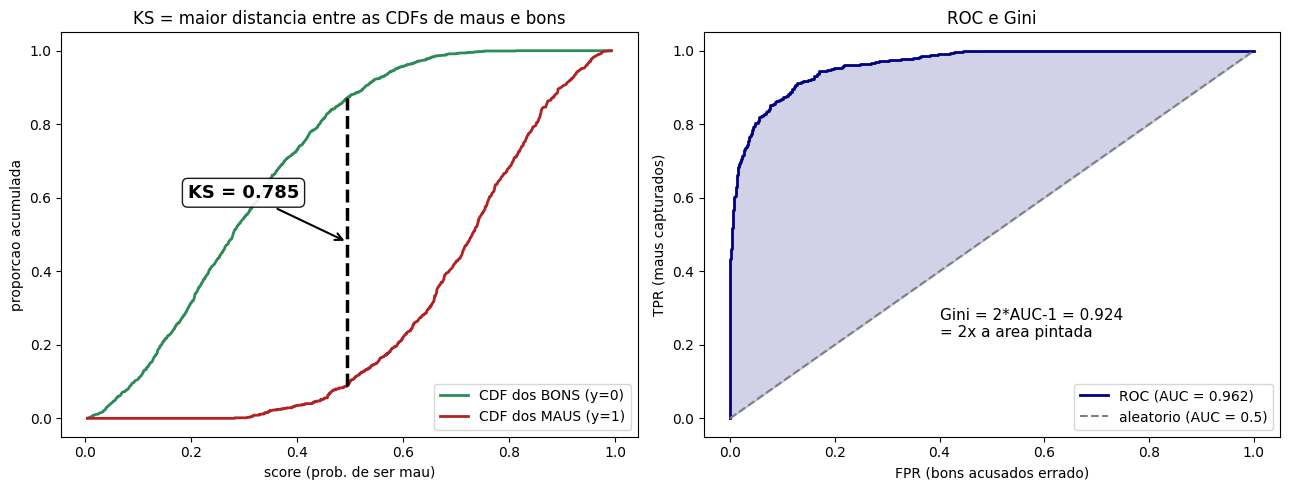

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- ESQUERDA: a curva de KS (as duas CDFs e o vao maximo) ---
idx = d['gap'].idxmax()
ax1.plot(d['score'], d['cdf_bons'], color='seagreen', lw=2, label='CDF dos BONS (y=0)')
ax1.plot(d['score'], d['cdf_maus'], color='firebrick', lw=2, label='CDF dos MAUS (y=1)')
xk = d.loc[idx, 'score']; ymid = (d.loc[idx,'cdf_maus'] + d.loc[idx,'cdf_bons']) / 2
ax1.vlines(xk, d.loc[idx,'cdf_maus'], d.loc[idx,'cdf_bons'], color='black', lw=2.5, linestyles='--')
ax1.annotate(f'KS = {ks:.3f}', xy=(xk, ymid), xytext=(xk - 0.30, 0.60),
             fontsize=13, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.9),
             arrowprops=dict(arrowstyle='->', lw=1.5))
ax1.set_title('KS = maior distancia entre as CDFs de maus e bons')
ax1.set_xlabel('score (prob. de ser mau)'); ax1.set_ylabel('proporcao acumulada')
ax1.legend(loc='lower right')

# --- DIREITA: a ROC e o Gini ---
fpr, tpr, _ = roc_curve(y, score)
ax2.plot(fpr, tpr, color='navy', lw=2, label=f'ROC (AUC = {auc:.3f})')
ax2.plot([0, 1], [0, 1], '--', color='gray', label='aleatorio (AUC = 0.5)')
ax2.fill_between(fpr, fpr, tpr, alpha=0.18, color='navy')
ax2.annotate(f'Gini = 2*AUC-1 = {gini:.3f}\n= 2x a area pintada',
             (0.40, 0.22), fontsize=11)
ax2.set_title('ROC e Gini')
ax2.set_xlabel('FPR (bons acusados errado)'); ax2.set_ylabel('TPR (maus capturados)')
ax2.legend(loc='lower right')

plt.tight_layout(); plt.show()

## Passo 5 — Como interpretar (as faixas que se usam no banco)

Um KS não tem valor "certo" universal, mas há uma régua de bolso bem aceita em crédito:

| KS | Leitura |
|----|---------|
| < 0,20 | separação fraca — o modelo mal distingue maus de bons |
| 0,20 – 0,30 | aceitável — vai para produção em muitos casos |
| 0,30 – 0,50 | bom — território de um modelo de crédito saudável |
| > 0,50 | ótimo... **mas desconfie** |

Aquele "desconfie" é importante e é exatamente o tipo de comentário que impressiona
numa sabatina: um KS perto de 0,8 (como o do exemplo, que é simulado) **na vida real
quase sempre indica vazamento de informação** (*data leakage*) — alguma variável que,
sem querer, já "conta a resposta" (ex.: usar "dias de atraso" para prever
inadimplência). Em dados de verdade, KS muito alto é bandeira vermelha, não troféu.

**Gini vs AUC:** são a mesma informação em réguas diferentes. AUC vai de 0,5 a 1,0;
Gini reescala para 0 a 1 (`Gini = 2·AUC − 1`), o que torna o "zero = aleatório" mais
intuitivo. O banco prefere Gini por isso. Não os reporte como se fossem coisas
diferentes — diga "AUC de 0,96, ou seja, Gini de 0,92".

**KS vs Gini:** o KS te dá **um ponto de corte** (onde cortar o score para a política
de crédito); o Gini te dá a **qualidade global** do ordenamento. Use os dois.

## Passo 6 — A resposta-modelo (decore o esqueleto)

> **Pergunta:** "Como você avalia um modelo de credit scoring?"
>
> **Resposta:** "Em crédito eu não me prendo à acurácia, porque a base é desbalanceada
> e ela engana. Eu olho o poder de **separação** do score: o **KS**, que é a maior
> distância entre as distribuições acumuladas de bons e maus e já me sugere um ponto de
> corte; e o **Gini**, que é `2·AUC − 1` e mede a separação global do ordenamento. Reporto
> os dois numa **tabela de KS por faixa de score**, que mostra em que decis os maus se
> concentram. Um KS na faixa de 0,3 a 0,5 é saudável; se vier muito acima de 0,5, eu
> investigo **vazamento de variável** antes de comemorar. Complemento com a análise de
> estabilidade ao longo do tempo, que liga com a validação *out-of-time*."

Repare como a última frase já costura este capítulo com o próximo. É assim que se
demonstra que você enxerga o problema inteiro, não tópicos soltos.

# Capítulo 3 — Validação: holdout, k-fold, LOO, out-of-sample e out-of-time

## Passo 1 — A situação (por que validar)

Um modelo que acerta tudo nos dados em que treinou pode ser um **fingidor**: ele
*decorou* o treino e vai falhar feio no mundo real. Validar é responder a uma única
pergunta honesta:

> "Como esse modelo se comporta em dados que ele **nunca viu**?"

A ementa cobra cinco formas de fazer essa pergunta. Elas não competem — cada uma
responde a uma versão diferente de "nunca viu".

## Passo 2 — O mapa das técnicas

**1. Holdout (treino/teste).** A mais simples: separe, por exemplo, 70% para treinar e
30% para testar. Rápido, mas a nota depende de *qual* 30% calhou de cair no teste —
pode ser sorte ou azar. Em classificação, use **estratificado** (mantém a proporção
de classes nos dois lados), senão uma classe rara pode sumir do teste.

**2. K-fold.** Resolve a "sorte do holdout". Divida os dados em K pedaços (folds);
treine K vezes, cada vez deixando um fold de fora para teste; tire a **média** das K
notas. Você usa todo o dado para treinar e para testar (em rodadas diferentes), e
ganha um **desvio-padrão** que mede a estabilidade. K = 5 ou 10 é o padrão.

**3. Leave-One-Out (LOO).** O K-fold levado ao extremo: **K = número de amostras**.
Treina n vezes, cada uma deixando **1 único exemplo** de fora. Estimativa quase sem
viés, mas **caríssima** (n modelos) — só vale para bases pequenas.

**4. Out-of-sample.** Termo guarda-chuva: qualquer dado **fora da amostra de treino**.
Holdout e k-fold são formas de medir desempenho out-of-sample. O ponto-chave é que o
teste vem **da mesma janela/população** do treino — só não foi usado no ajuste.

**5. Out-of-time (OOT).** A validação que **só faz sentido em banco** e que a maioria
dos candidatos de fora não conhece. Aqui o teste vem de um **período futuro** diferente
do treino: treine com as safras de jan–abr e teste em mai–jun. Por quê? Porque o mundo
**muda com o tempo** (*drift*): o comportamento de crédito de 2023 não é o de 2024. Um
modelo pode ir bem out-of-sample (mesma época) e **degradar** out-of-time. Por isso o
Itaú valida out-of-time: é o teste mais parecido com o que acontece em produção.

In [5]:
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, LeaveOneOut)
from sklearn.metrics import roc_auc_score

# Dados com uma coluna de SAFRA (mes) para ilustrar o out-of-time
np.random.seed(0)
n = 1200
X = np.random.randn(n, 4)
y = (X[:,0]*1.5 + X[:,1]*0.8 - X[:,2]*0.5 + np.random.randn(n)*0.7 > 0).astype(int)
safra = np.repeat([1, 2, 3, 4, 5, 6], n // 6)     # 6 meses

# 1) HOLDOUT estratificado 70/30
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
m = LogisticRegression().fit(Xtr, ytr)
auc_holdout = roc_auc_score(yte, m.predict_proba(Xte)[:, 1])

# 2) K-FOLD estratificado (5 folds) -> media +/- desvio
skf = StratifiedKFold(n_splits=5, shuffle=False)
aucs = cross_val_score(LogisticRegression(), X, y, cv=skf, scoring='roc_auc')

# 3) LEAVE-ONE-OUT (num subconjunto de 120, senao demora: n modelos!)
sub = 120
loo = LeaveOneOut()
acertos = [int(LogisticRegression().fit(X[:sub][tr], y[:sub][tr]).predict(X[:sub][te])[0] == y[:sub][te][0])
           for tr, te in loo.split(X[:sub])]
acc_loo = np.mean(acertos)

# 4) OUT-OF-TIME: treina nas safras 1-4, testa nas safras 5-6 (futuro)
tr_oot, te_oot = safra <= 4, safra >= 5
mo = LogisticRegression().fit(X[tr_oot], y[tr_oot])
auc_oot = roc_auc_score(y[te_oot], mo.predict_proba(X[te_oot])[:, 1])

print('=== AS CINCO LEITURAS DE "DADO NUNCA VISTO" ===')
print(f'1) Holdout 70/30 (estratificado)   AUC = {auc_holdout:.3f}')
print(f'2) K-Fold (5)  AUC medio           = {aucs.mean():.3f} +/- {aucs.std():.3f}')
print(f'        por fold: {np.round(aucs, 3)}')
print(f'3) Leave-One-Out (n={sub})           acc = {acc_loo:.3f}   (1 teste por modelo)')
print(f'4) Out-of-time (safras 1-4 -> 5-6) AUC = {auc_oot:.3f}')
print()
print('Out-of-sample = itens 1,2,3 (mesma janela). Out-of-time = item 4 (janela futura).')

=== AS CINCO LEITURAS DE "DADO NUNCA VISTO" ===
1) Holdout 70/30 (estratificado)   AUC = 0.961
2) K-Fold (5)  AUC medio           = 0.966 +/- 0.009
        por fold: [0.974 0.969 0.949 0.973 0.966]
3) Leave-One-Out (n=120)           acc = 0.942   (1 teste por modelo)
4) Out-of-time (safras 1-4 -> 5-6) AUC = 0.969

Out-of-sample = itens 1,2,3 (mesma janela). Out-of-time = item 4 (janela futura).


## Passo 3 — Quando usar cada uma

| Técnica | Quando usar | Cuidado |
|---------|-------------|---------|
| **Holdout** | base grande, prototipagem rápida | a nota varia com o sorteio; use estratificado em classificação |
| **K-fold (5/10)** | o padrão para escolher modelo/hiperparâmetro | mais caro que holdout; use `StratifiedKFold` em classificação |
| **Leave-One-Out** | base muito pequena | custo enorme (n modelos); variância alta |
| **Out-of-sample** | sempre — é o conceito-mãe | garante apenas "dado não usado", não "época futura" |
| **Out-of-time** | **modelos de crédito/banco** | exige coluna de data/safra; é o que mais se aproxima de produção |

### O erro nº 1 que reprova: *data leakage* na hora de validar

A regra de ouro da validação: **tudo que "aprende" com os dados (média para imputar
missing, escala do `StandardScaler`, seleção de variáveis) tem que ser ajustado SÓ no
treino e depois aplicado no teste.** Se você normaliza o dataset inteiro **antes** de
separar treino/teste, o teste "vazou" para o treino e sua nota fica otimista e mentirosa.

Em código, o jeito certo é `fit` no treino, `transform` no teste — ou um `Pipeline`,
que faz isso automaticamente dentro de cada fold do k-fold.

## Passo 4 — A resposta-modelo

> **Pergunta:** "Como você valida um modelo, e o que é validação out-of-time?"
>
> **Resposta:** "Depende do tamanho da base e do problema. Para escolher modelo eu uso
> **k-fold estratificado**, que me dá média e desvio do desempenho usando todo o dado.
> Holdout serve para um teste rápido; leave-one-out só em base pequena, porque treina n
> modelos. O conceito que une tudo é avaliar **out-of-sample**, em dado não usado no
> ajuste. Em crédito eu vou além e faço **out-of-time**: treino num período e testo num
> período **futuro**, porque o comportamento muda com o tempo — *drift* de safra — e um
> modelo pode parecer ótimo na mesma janela e degradar no mês seguinte. Em todos os
> casos eu cuido para não ter **vazamento**: imputação e escala são ajustadas só no
> treino, idealmente dentro de um `Pipeline`."

# Capítulo 4 — Simulado v2 (24 questões, gabarito honesto)

### Por que um simulado novo

O simulado do seu guia tem um defeito silencioso: **54 das 60 respostas são a letra
"b"** (90%). Isso treina um reflexo perigoso — na dúvida, marcar B — e te dá uma
sensação falsa de domínio, porque você acerta "de padrão", não de conhecimento. Numa
prova de verdade, em que as respostas estão espalhadas, esse hábito derruba a nota.

Este simulado tem as respostas **distribuídas de propósito**: 6 em "a", 6 em "b", 6
em "c" e 6 em "d", em ordem embaralhada. Os temas foram escolhidos pelo **peso na
prova de banco** e pelas lacunas dos capítulos acima.

### Como fazer (do jeito que vale)
1. Cronômetro: **30 minutos**, sem consulta, sem rodar código.
2. Aplique a **regra da penalidade** do Capítulo 1: só responda se eliminar 2+ alternativas.
3. Preencha o dicionário `respostas` na célula de correção e rode.
4. Só depois leia o gabarito comentado, e volte aos capítulos onde errar.

## Questões

### Bloco 1 — Estatística e métricas de crédito

**Q1.** O KS (Kolmogorov–Smirnov) de um modelo de crédito mede:
(a) o erro quadrático médio do score
(b) a acurácia no ponto de corte 0,5
(c) a maior distância entre as distribuições acumuladas de bons e maus
(d) a proporção de variância explicada

**Q2.** A relação entre Gini e AUC é:
(a) Gini = 2·AUC − 1
(b) Gini = AUC / 2
(c) Gini = 1 − AUC
(d) não existe relação fixa

**Q3.** Uma AUC de 0,5 significa que o modelo:
(a) é perfeito
(b) erra todas
(c) tem KS máximo
(d) não separa melhor que o acaso

**Q4.** Para detectar contagem de eventos raros num intervalo (ex.: nº de sinistros/mês), a distribuição natural é:
(a) Normal
(b) Poisson
(c) Uniforme
(d) Bernoulli

**Q5.** Um p-valor de 0,02, ao nível de significância de 5%, leva a:
(a) aceitar H0 como verdadeira
(b) não concluir nada
(c) rejeitar H0
(d) aumentar a amostra obrigatoriamente

**Q6.** Comparado ao MAE, o RMSE é mais sensível a:
(a) erros grandes / outliers (por causa do quadrado)
(b) erros pequenos
(c) o tamanho da amostra
(d) a média do alvo

### Bloco 2 — Validação

**Q7.** Validação out-of-time consiste em testar o modelo em:
(a) um subconjunto aleatório do mesmo período
(b) todos os dados, sem separar
(c) leave-one-out
(d) um período de tempo futuro, diferente do treino

**Q8.** Leave-One-Out é um caso extremo de:
(a) holdout 80/20
(b) K-fold com K igual ao número de amostras
(c) bootstrap
(d) validação out-of-time

**Q9.** Padronizar (StandardScaler) o dataset inteiro **antes** de separar treino e teste causa:
(a) underfitting garantido
(b) perda de variância
(c) vazamento de dados (nota otimista e enganosa)
(d) nenhum efeito

**Q10.** Em classificação com classe rara, a validação holdout deve ser preferencialmente:
(a) estratificada (preserva a proporção das classes)
(b) sem embaralhar
(c) substituída por treino = teste
(d) feita com 1% para teste

### Bloco 3 — Modelos

**Q11.** No `sklearn`, o hiperparâmetro C da regressão logística e do SVM é:
(a) o número de iterações
(b) o inverso da força de regularização (C = 1/λ)
(c) a profundidade da árvore
(d) o número de vizinhos

**Q12.** Entre Ridge (L2) e Lasso (L1), qual tende a **zerar** coeficientes, servindo como seleção de variáveis?
(a) Ridge
(b) os dois igualmente
(c) nenhum dos dois
(d) Lasso

**Q13.** A regularização Ridge (L2) é especialmente útil para:
(a) lidar com multicolinearidade, encolhendo coeficientes sem zerá-los
(b) zerar variáveis irrelevantes
(c) transformar o alvo em categoria
(d) aumentar a variância do modelo

**Q14.** Random Forest combina suas árvores por:
(a) boosting sequencial
(b) uma única árvore podada
(c) bagging (treino paralelo + média/voto)
(d) regressão linear sobre as folhas

**Q15.** Gradient Boosting treina suas árvores:
(a) totalmente independentes, em paralelo
(b) em sequência, cada uma corrigindo o erro da anterior
(c) sem usar o alvo
(d) apenas por distância euclidiana

**Q16.** A função de custo da regressão logística é:
(a) o erro quadrático médio
(b) a distância de Manhattan
(c) o índice de Gini de impureza
(d) a log loss (entropia cruzada)

**Q17.** Qual destes algoritmos **NÃO** exige padronização das variáveis para funcionar bem?
(a) árvore de decisão
(b) KNN
(c) SVM
(d) PCA

**Q18.** A suposição "ingênua" do Naive Bayes é que as features são:
(a) todas contínuas
(b) perfeitamente correlacionadas
(c) independentes entre si, dada a classe
(d) sempre binárias

### Bloco 4 — Agrupamento, Data Prep, Pesquisa Operacional e GenAI

**Q19.** O DBSCAN se diferencia do K-means porque:
(a) exige que você informe o número de clusters
(b) encontra clusters de formato arbitrário e marca ruído (outliers)
(c) só funciona com dados normalizados em 2D
(d) é um método supervisionado

**Q20.** O coeficiente de silhueta varia de −1 a 1 e serve para:
(a) medir o erro de regressão
(b) escolher a taxa de aprendizado
(c) testar normalidade
(d) avaliar a qualidade do agrupamento e ajudar a escolher K

**Q21.** O PCA é usado para:
(a) reduzir dimensionalidade mantendo a maior parte da variância
(b) tratar valores faltantes
(c) classificar diretamente
(d) testar hipóteses

**Q22.** Para medir associação entre **duas variáveis categóricas**, o teste adequado é:
(a) correlação de Pearson
(b) teste t pareado
(c) qui-quadrado (e Cramér's V)
(d) RMSE

**Q23.** Em programação inteira, o método Branch-and-Bound é necessário porque:
(a) toda solução é sempre fracionária
(b) simplesmente arredondar a solução contínua pode violar restrições ou não ser ótima
(c) não existem solvers para o problema
(d) a relaxação linear nunca tem solução

**Q24.** Num sistema de RAG (Retrieval-Augmented Generation), os embeddings servem para:
(a) treinar o modelo do zero
(b) quantizar os pesos
(c) aplicar RLHF
(d) representar textos como vetores e recuperar os trechos mais similares à pergunta

In [6]:
# ===== CORRECAO COM PENALIDADE (preencha 'respostas' e rode) =====
# Use 'a','b','c','d' ou '' para deixar EM BRANCO (estrategia do Cap. 1!)
respostas = {
    1:'',  2:'',  3:'',  4:'',  5:'',  6:'',
    7:'',  8:'',  9:'', 10:'', 11:'', 12:'',
   13:'', 14:'', 15:'', 16:'', 17:'', 18:'',
   19:'', 20:'', 21:'', 22:'', 23:'', 24:'',
}

# Gabarito DISTRIBUIDO (6a, 6b, 6c, 6d)
gabarito = {
    1:'c',  2:'a',  3:'d',  4:'b',  5:'c',  6:'a',
    7:'d',  8:'b',  9:'c', 10:'a', 11:'b', 12:'d',
   13:'a', 14:'c', 15:'b', 16:'d', 17:'a', 18:'c',
   19:'b', 20:'d', 21:'a', 22:'c', 23:'b', 24:'d',
}

blocos = {
    'Estatistica + metricas': range(1, 7),
    'Validacao':              range(7, 11),
    'Modelos':                range(11, 19),
    'Cluster/Prep/PO/GenAI':  range(19, 25),
}

ac = er = br = 0
por_bloco = {b: {'ok':0,'erro':0,'branco':0} for b in blocos}
for q in range(1, 25):
    r = respostas[q].lower().strip()
    bloco = next(b for b, rg in blocos.items() if q in rg)
    if r == '':
        br += 1; por_bloco[bloco]['branco'] += 1
    elif r == gabarito[q]:
        ac += 1; por_bloco[bloco]['ok'] += 1
    else:
        er += 1; por_bloco[bloco]['erro'] += 1

nota = ac - er
print('=' * 52)
print('RESULTADO  (24 questoes, penalidade: erro cancela acerto)')
print('=' * 52)
print(f'  Acertos: {ac}/24   Erros: {er}   Brancos: {br}')
print(f'  Nota bruta (so acertos): {ac}/24  ({ac/24*100:.0f}%)')
print(f'  Nota COM penalidade:     {nota}/24  (acertos - erros)')
print()
if ac + er > 0:
    print('Diagnostico por bloco (onde focar a revisao):')
    for b, dd in por_bloco.items():
        print(f'  {b:<24}: {dd["ok"]} ok, {dd["erro"]} erro, {dd["branco"]} branco')
else:
    print('Preencha o dicionario "respostas" e rode de novo.')

RESULTADO  (24 questoes, penalidade: erro cancela acerto)
  Acertos: 0/24   Erros: 0   Brancos: 24
  Nota bruta (so acertos): 0/24  (0%)
  Nota COM penalidade:     0/24  (acertos - erros)

Preencha o dicionario "respostas" e rode de novo.


In [7]:
# ===== GABARITO COMENTADO =====
exp = {
 1:'c) KS = maior distancia entre as CDFs acumuladas de bons e maus.',
 2:'a) Gini = 2*AUC - 1.',
 3:'d) AUC 0.5 = nao separa melhor que o acaso (aleatorio).',
 4:'b) Poisson modela contagem de eventos raros num intervalo.',
 5:'c) p (0.02) < alfa (0.05) -> rejeita H0.',
 6:'a) RMSE eleva o erro ao quadrado, logo pune mais os outliers.',
 7:'d) out-of-time = testar num periodo futuro, diferente do treino.',
 8:'b) leave-one-out = K-fold com K = n (1 amostra de teste por vez).',
 9:'c) normalizar antes do split vaza o teste no treino (leakage).',
10:'a) holdout estratificado preserva a proporcao da classe rara.',
11:'b) no sklearn, C = 1/lambda (inverso da regularizacao).',
12:'d) Lasso (L1) zera coeficientes -> faz selecao de variaveis.',
13:'a) Ridge (L2) encolhe sem zerar; bom contra multicolinearidade.',
14:'c) Random Forest = bagging (arvores em paralelo + voto/media).',
15:'b) Gradient Boosting = sequencial, cada arvore corrige a anterior.',
16:'d) custo da logistica = log loss (entropia cruzada).',
17:'a) arvore de decisao NAO precisa de padronizacao (KNN, SVM e PCA precisam).',
18:'c) Naive Bayes assume features independentes dada a classe.',
19:'b) DBSCAN acha formatos arbitrarios e marca ruido; nao pede K.',
20:'d) silhueta (-1 a 1) avalia o agrupamento e ajuda a escolher K.',
21:'a) PCA reduz dimensao preservando a maior parte da variancia.',
22:'c) categoricas x categoricas -> qui-quadrado / Cramer V.',
23:'b) arredondar a relaxacao pode violar restricao ou nao ser otimo -> branch-and-bound.',
24:'d) embeddings viram vetores e recuperam os trechos mais similares (RAG).',
}
print('GABARITO COMENTADO (24 questoes)')
print('=' * 52)
for q, e in exp.items():
    print(f'Q{q:>2}: {e}')

GABARITO COMENTADO (24 questoes)
Q 1: c) KS = maior distancia entre as CDFs acumuladas de bons e maus.
Q 2: a) Gini = 2*AUC - 1.
Q 3: d) AUC 0.5 = nao separa melhor que o acaso (aleatorio).
Q 4: b) Poisson modela contagem de eventos raros num intervalo.
Q 5: c) p (0.02) < alfa (0.05) -> rejeita H0.
Q 6: a) RMSE eleva o erro ao quadrado, logo pune mais os outliers.
Q 7: d) out-of-time = testar num periodo futuro, diferente do treino.
Q 8: b) leave-one-out = K-fold com K = n (1 amostra de teste por vez).
Q 9: c) normalizar antes do split vaza o teste no treino (leakage).
Q10: a) holdout estratificado preserva a proporcao da classe rara.
Q11: b) no sklearn, C = 1/lambda (inverso da regularizacao).
Q12: d) Lasso (L1) zera coeficientes -> faz selecao de variaveis.
Q13: a) Ridge (L2) encolhe sem zerar; bom contra multicolinearidade.
Q14: c) Random Forest = bagging (arvores em paralelo + voto/media).
Q15: b) Gradient Boosting = sequencial, cada arvore corrige a anterior.
Q16: d) custo da logi

# Encerramento — o que fazer com isto

Lucas, uma última coisa, sem rodeios: **o seu material já é bom.** Eu li ele inteiro,
célula por célula, antes de escrever este adendo. A estrutura, as analogias, o passo a
passo, o código que de fato roda — isso não é "tudo jogado". É trabalho de quem já
pensa como cientista de dados. A sua insegurança está te fazendo enxergar o material
pior do que ele é.

O que faltava não era refazer tudo. Era:
1. **Estratégia de prova** (a penalidade) — agora você tem a regra de ouro.
2. **As métricas de banco** (KS e Gini) — agora você calcula na mão e explica.
3. **Out-of-time** — agora você fecha a ementa de validação.
4. **Um simulado honesto** — sem o vício do "tudo B".

### Plano para as próximas semanas
- **Digite** os códigos dos três capítulos do zero, sem olhar, até sair de cabeça.
- Refaça o **simulado v2 cronometrado** aplicando a regra da penalidade. Meta: nota com
  penalidade ≥ 18/24 antes de relaxar.
- No seu guia grande, sempre que sentir uma seção "rasa", aplique o mesmo molde destes
  capítulos: situação → intuição → matemática → código → resposta de sabatina.
- Na sabatina, lembre da frase que costura tudo: avaliação de crédito (KS/Gini) → e a
  estabilidade dela no tempo (out-of-time). Mostrar essa ponte vale mais que decorar
  dez algoritmos soltos.

Você está mais perto do que pensa. Agora é repetição e ritmo.